In [58]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


# CNN Permanent: Train Once, Reuse Always (Traffic Sign Classification)
This notebook mirrors your CNN workflow but persists the model and training history so that after a restart you can load the saved model and immediately run inference without retraining.

In [59]:
# Section 1: Set Up Environment and Imports
import os, json, pickle, pathlib, random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, load_model, model_from_json
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, CSVLogger

In [60]:
# Section 2: Configure Paths and Constants
BASE_DIR = "/Users/komalsaivulchi/Downloads/traffic-sign-detection-main"
DATA_DIR = f"{BASE_DIR}/archive/Train"
TEST_DIR = f"{BASE_DIR}/archive/Test"
MODEL_DIR = f"{BASE_DIR}/CNN_permanent/model"
Path(MODEL_DIR).mkdir(parents=True, exist_ok=True)
MODEL_FILE = f"{MODEL_DIR}/traffic_sign_cnn_saved"  # base path
MODEL_FILE_KERAS = f"{MODEL_FILE}.keras"  # Keras v3 native format
WEIGHTS_FILE = f"{MODEL_DIR}/traffic_sign_cnn.weights.h5"  # adjust extension
ARCH_FILE = f"{MODEL_DIR}/traffic_sign_cnn_arch.json"
LABELS_FILE = f"{MODEL_DIR}/label_encoder.pkl"
HISTORY_JSON = f"{MODEL_DIR}/training_history.json"
HISTORY_CSV = f"{MODEL_DIR}/training_history.csv"
IMG_HEIGHT, IMG_WIDTH, CHANNELS = 32, 32, 3
NUM_CLASSES = 43
BATCH_SIZE = 32
EPOCHS = 15
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

In [61]:
# Section 2A: Training Control Flags & Live Logger (set FORCE_RETRAIN=True to retrain)
FORCE_RETRAIN = False  # change to True only when you want to force a fresh training run
LIVE_LOGS = True       # set False to suppress per-epoch custom prints

from tensorflow.keras.callbacks import Callback

class LiveLogger(Callback):
    def on_train_begin(self, logs=None):
        print(f"Starting training for {self.params.get('epochs', '?')} epochs...")
    def on_epoch_end(self, epoch, logs=None):
        if logs is None: logs = {}
        msg = (f"Epoch {epoch+1}/{self.params.get('epochs','?')} | "
               f"loss={logs.get('loss'):.4f} acc={logs.get('accuracy'):.4f} "
               f"val_loss={logs.get('val_loss'):.4f} val_acc={logs.get('val_accuracy'):.4f}")
        print(msg)
    def on_train_end(self, logs=None):
        print("Training complete.")

print(f"FORCE_RETRAIN={FORCE_RETRAIN} | LIVE_LOGS={LIVE_LOGS}")
print("(If FORCE_RETRAIN=False and saved model exists, Section 10 will load instead of retrain.)")

FORCE_RETRAIN=False | LIVE_LOGS=True
(If FORCE_RETRAIN=False and saved model exists, Section 10 will load instead of retrain.)


In [62]:
# Class label names mapping (GTSRB)
class_labels = {
    0: "Speed limit (20km/h)", 1: "Speed limit (30km/h)", 2: "Speed limit (50km/h)",
    3: "Speed limit (60km/h)", 4: "Speed limit (70km/h)", 5: "Speed limit (80km/h)",
    6: "End of speed limit (80km/h)", 7: "Speed limit (100km/h)", 8: "Speed limit (120km/h)",
    9: "No passing", 10: "No passing for vehicles over 3.5 metric tons",
    11: "Right-of-way at the next intersection", 12: "Priority road", 13: "Yield",
    14: "Stop", 15: "No vehicles", 16: "Vehicles over 3.5 metric tons prohibited",
    17: "No entry", 18: "General caution", 19: "Dangerous curve to the left",
    20: "Dangerous curve to the right", 21: "Double curve", 22: "Bumpy road",
    23: "Slippery road", 24: "Road narrows on the right", 25: "Road work",
    26: "Traffic signals", 27: "Pedestrians", 28: "Children crossing",
    29: "Bicycles crossing", 30: "Beware of ice/snow", 31: "Wild animals crossing",
    32: "End of all speed and passing limits", 33: "Turn right ahead",
    34: "Turn left ahead", 35: "Ahead only", 36: "Go straight or right",
    37: "Go straight or left", 38: "Keep right", 39: "Keep left",
    40: "Roundabout mandatory", 41: "End of no passing",
    42: "End of no passing by vehicles over 3.5 metric tons"
}
print("Loaded class label names (43 classes).")

Loaded class label names (43 classes).


In [63]:
# Section 3: Load and Inspect Raw Dataset
class_dirs = sorted([d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))])
print(f"Found {len(class_dirs)} classes.")
counts = {}
for cls in class_dirs:
    counts[cls] = len(os.listdir(os.path.join(DATA_DIR, cls)))
print("Sample counts per class (first 10):", dict(list(counts.items())[:10]))

Found 43 classes.
Sample counts per class (first 10): {'0': 210, '1': 2220, '10': 2010, '11': 1320, '12': 2100, '13': 2160, '14': 780, '15': 630, '16': 420, '17': 1110}


In [65]:
# Section 4: Preprocess Images and Encode Labels
images, labels = [], []
for cls in class_dirs:
    folder = os.path.join(DATA_DIR, cls)
    for img_name in os.listdir(folder):
        img_path = os.path.join(folder, img_name)
        img = cv2.imread(img_path)
        if img is None:
            continue
        img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
        images.append(img)
        labels.append(int(cls))
X = np.array(images, dtype=np.float32) / 255.0
y_numeric = np.array(labels, dtype=np.int32)
print(f"Loaded X: {X.shape}, y: {y_numeric.shape}")
le = LabelEncoder()
y_encoded = le.fit_transform(y_numeric)
y_onehot = to_categorical(y_encoded, NUM_CLASSES)
print("LabelEncoder fitted. Example mapping:", list(zip(le.classes_[:5], le.transform(le.classes_[:5]))))

Loaded X: (39209, 32, 32, 3), y: (39209,)
LabelEncoder fitted. Example mapping: [(np.int32(0), np.int64(0)), (np.int32(1), np.int64(1)), (np.int32(2), np.int64(2)), (np.int32(3), np.int64(3)), (np.int32(4), np.int64(4))]


In [66]:
# Section 5: Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_onehot, test_size=0.2, random_state=42, stratify=y_onehot.argmax(axis=1)
 )
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (31367, 32, 32, 3), Test: (7842, 32, 32, 3)


In [67]:
# Section 6: Data Augmentation Pipeline
train_datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    shear_range=0.1,
    horizontal_flip=False
 )
train_generator = train_datagen.flow(X_train, y_train, batch_size=BATCH_SIZE)

In [68]:
# Section 7: Define CNN Architecture (similar to CNN.ipynb)
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, CHANNELS)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')
])
model.summary()

/Users/komalsaivulchi/Downloads/traffic-sign-detection-main/.venv/lib/python3.9/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 43)             │         5,547 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 320,363 (1.22 MB)

 Trainable params: 320,171 (1.22 MB)

 Non-trainable params: 192 (768.00 B)

In [69]:
# Section 8: Compile Model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [70]:
# Section 9: Configure Callbacks
checkpoint_cb = ModelCheckpoint(WEIGHTS_FILE, monitor='val_accuracy', save_best_only=True, verbose=1)
early_cb = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1)
reduce_lr_cb = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
csv_logger_cb = CSVLogger(HISTORY_CSV, append=False)
callbacks = [checkpoint_cb, early_cb, reduce_lr_cb, csv_logger_cb]

In [71]:
# Section 10: Conditional Load or Train Model
history = None
existing = os.path.exists(MODEL_FILE_KERAS)
if existing and not FORCE_RETRAIN:
    print(f"Loading existing model from: {MODEL_FILE_KERAS}")
    model = load_model(MODEL_FILE_KERAS)
    if os.path.exists(WEIGHTS_FILE):
        model.load_weights(WEIGHTS_FILE)
        print("Loaded best weights.")
    if os.path.exists(HISTORY_CSV):
        print(f"Found training history CSV at: {HISTORY_CSV}")
else:
    if existing and FORCE_RETRAIN:
        print("FORCE_RETRAIN=True -> retraining despite existing model.")
    else:
        print("No saved model found. Training now…")
    extra_callbacks = callbacks[:]
    if LIVE_LOGS:
        extra_callbacks.append(LiveLogger())
    history = model.fit(
        train_generator,
        epochs=EPOCHS,
        validation_data=(X_test, y_test),
        callbacks=extra_callbacks,
        verbose=0  # suppress default Keras epoch line; LiveLogger prints instead
    )
    try:
        with open(HISTORY_JSON, 'w') as f:
            json.dump(history.history, f)
        print(f"Saved history to: {HISTORY_JSON}")
    except Exception as e:
        print("Warning: could not save history JSON:", e)

Loading existing model from: /Users/komalsaivulchi/Downloads/traffic-sign-detection-main/CNN_permanent/model/traffic_sign_cnn_saved.keras
Loaded best weights.
Found training history CSV at: /Users/komalsaivulchi/Downloads/traffic-sign-detection-main/CNN_permanent/model/training_history.csv


/Users/komalsaivulchi/Downloads/traffic-sign-detection-main/.venv/lib/python3.9/site-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 14 variables whereas the saved optimizer has 26 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [72]:
# Section 11: Evaluate Model Performance (robust, no retraining)
from tensorflow.keras.models import load_model

# 1) Ensure model is loaded
if 'model' not in globals() or model is None:
    if os.path.exists(MODEL_FILE_KERAS):
        model = load_model(MODEL_FILE_KERAS)
        if os.path.exists(WEIGHTS_FILE):
            try:
                model.load_weights(WEIGHTS_FILE)
                print("Loaded best weights.")
            except Exception as e:
                print("Weights load warning:", e)
        print("Model loaded for evaluation.")
    else:
        raise FileNotFoundError("Saved model not found. Please run training once to create it.")

# 2) Ensure test data exists (rebuild if needed)
need_data = ('X_test' not in globals()) or ('y_test' not in globals())
if need_data:
    print("Rebuilding test data (this runs only if not already in memory)…")
    # Discover class folders
    class_dirs = sorted([d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))])
    images, labels = [], []
    for cls in class_dirs:
        folder = os.path.join(DATA_DIR, cls)
        for img_name in os.listdir(folder):
            img_path = os.path.join(folder, img_name)
            img = cv2.imread(img_path)
            if img is None:
                continue
            img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
            images.append(img)
            labels.append(int(cls))
    X = np.array(images, dtype=np.float32) / 255.0
    y_numeric = np.array(labels, dtype=np.int32)
    from tensorflow.keras.utils import to_categorical
    y_onehot = to_categorical(y_numeric, NUM_CLASSES)
    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_onehot, test_size=0.2, random_state=42, stratify=y_onehot.argmax(axis=1)
    )
    print(f"Rebuilt splits -> Train: {X_train.shape}, Test: {X_test.shape}")

# 3) Evaluate
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc:.4f} | Test Loss: {test_loss:.4f}")

Test Accuracy: 0.9969 | Test Loss: 0.0127


In [73]:
# Section 12: Persist Artifacts (Model, Weights, Architecture, LabelEncoder)
if history is not None:
    model.save(MODEL_FILE_KERAS)
    print(f"Saved full model to: {MODEL_FILE_KERAS}")
    model.save_weights(WEIGHTS_FILE)
    print(f"Saved weights to: {WEIGHTS_FILE}")
    with open(ARCH_FILE, 'w') as f: 
        f.write(model.to_json())
    print(f"Saved architecture JSON to: {ARCH_FILE}")
    with open(LABELS_FILE, 'wb') as f:
        pickle.dump(le, f)
    print(f"Saved LabelEncoder to: {LABELS_FILE}")
else:
    print("Skipped artifact save (model loaded from disk).")

Skipped artifact save (model loaded from disk).


Loaded training history from JSON: /Users/komalsaivulchi/Downloads/traffic-sign-detection-main/CNN_permanent/model/training_history.json


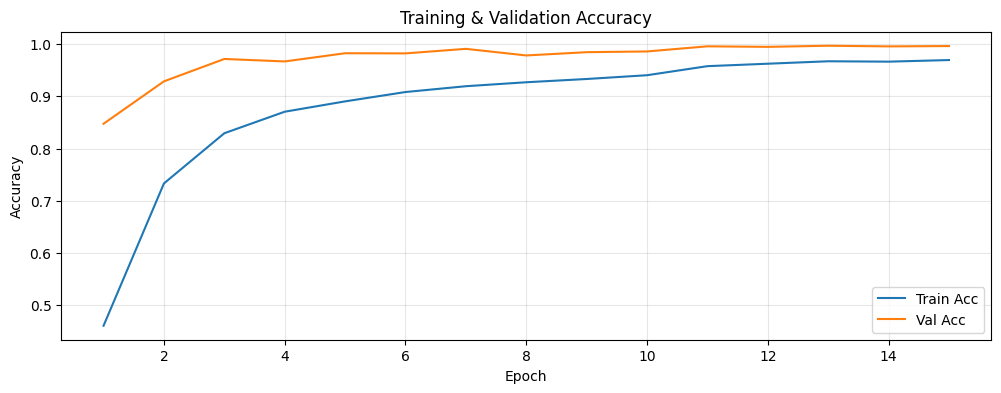

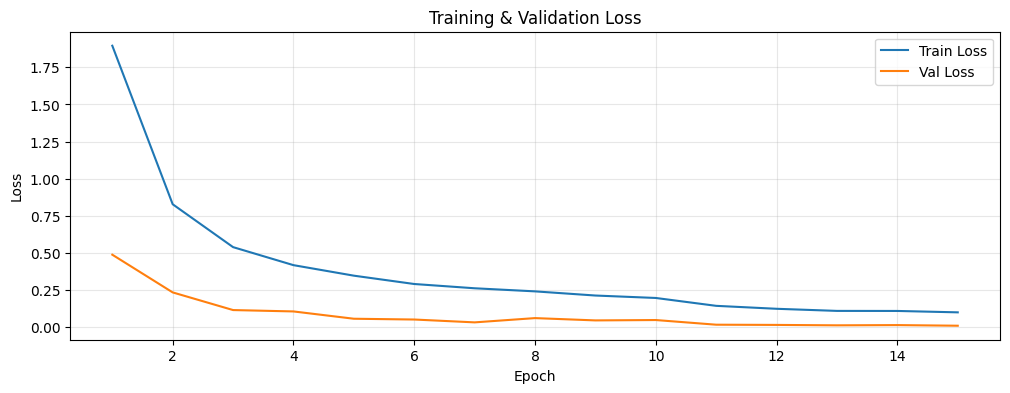

In [74]:
# Section 12A: Plot Training History (Accuracy & Loss)
import os, json
history_data = None

# 1) Use in-session history if available
if 'history' in globals() and history is not None:
    history_data = history.history
    print("Using in-session training history.")
# 2) Else try JSON artifact
elif os.path.exists(HISTORY_JSON):
    try:
        with open(HISTORY_JSON, 'r') as f:
            history_data = json.load(f)
        print(f"Loaded training history from JSON: {HISTORY_JSON}")
    except Exception as e:
        print("Failed to read HISTORY_JSON:", e)
# 3) Else try CSV artifact
elif os.path.exists(HISTORY_CSV):
    try:
        import pandas as pd
        df_hist = pd.read_csv(HISTORY_CSV)
        history_data = {col: df_hist[col].tolist() for col in df_hist.columns if col in ['loss','accuracy','val_loss','val_accuracy']}
        print(f"Loaded training history from CSV: {HISTORY_CSV}")
    except Exception as e:
        print("Failed to read HISTORY_CSV:", e)

if history_data is None:
    print("No training history available (model was loaded without prior artifacts).")
else:
    # Plot Accuracy
    epochs_range = range(1, len(history_data.get('accuracy', [])) + 1)
    if epochs_range:
        plt.figure(figsize=(12,4))
        if 'accuracy' in history_data:
            plt.plot(epochs_range, history_data['accuracy'], label='Train Acc')
        if 'val_accuracy' in history_data:
            plt.plot(epochs_range, history_data['val_accuracy'], label='Val Acc')
        plt.title('Training & Validation Accuracy')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.legend()
        plt.grid(alpha=0.3)
        plt.show()

    # Plot Loss
    epochs_range_loss = range(1, len(history_data.get('loss', [])) + 1)
    if epochs_range_loss:
        plt.figure(figsize=(12,4))
        if 'loss' in history_data:
            plt.plot(epochs_range_loss, history_data['loss'], label='Train Loss')
        if 'val_loss' in history_data:
            plt.plot(epochs_range_loss, history_data['val_loss'], label='Val Loss')
        plt.title('Training & Validation Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(alpha=0.3)
        plt.show()

# Section 12B: Per-Epoch Training Metrics (Tabular View)

In [75]:
# Section 12B (code): Display per-epoch metrics
import pandas as pd, os, json
hist_df = None
if 'history' in globals() and history is not None:
    print('Using in-session history for table.')
    hist_df = pd.DataFrame(history.history)
elif os.path.exists(HISTORY_JSON):
    try:
        with open(HISTORY_JSON,'r') as f: data_json = json.load(f)
        hist_df = pd.DataFrame(data_json)
        print('Loaded history from JSON.')
    except Exception as e:
        print('JSON load failed:', e)
elif os.path.exists(HISTORY_CSV):
    try:
        hist_df = pd.read_csv(HISTORY_CSV)
        print('Loaded history from CSV.')
    except Exception as e:
        print('CSV load failed:', e)

if hist_df is None:
    print('No history available to tabulate.')
else:
    # Standardize column names if needed
    col_map = {c:c for c in hist_df.columns}
    # Add epoch index 1-based
    hist_df.insert(0,'epoch', range(1, len(hist_df)+1))
    display(hist_df.head(len(hist_df)))
    # Summary
    if 'val_accuracy' in hist_df.columns:
        best_idx = hist_df['val_accuracy'].idxmax()
        best_row = hist_df.loc[best_idx]
        print(f"Best val_accuracy {best_row['val_accuracy']:.4f} at epoch {int(best_row['epoch'])}")
    elif 'accuracy' in hist_df.columns:
        best_idx = hist_df['accuracy'].idxmax()
        best_row = hist_df.loc[best_idx]
        print(f"Best accuracy {best_row['accuracy']:.4f} at epoch {int(best_row['epoch'])}")

Loaded history from JSON.


,epoch,accuracy,loss,val_accuracy,val_loss,learning_rate
0,1,0.460611,1.894985,0.847488,0.488157,0.0010
1,2,0.733191,0.827761,0.928717,0.234284,0.0010
2,3,0.829311,0.539079,0.971563,0.115443,0.0010
3,4,0.870533,0.417772,0.966845,0.106186,0.0010
4,5,0.890331,0.346962,0.982530,0.057018,0.0010
5,6,0.908248,0.290848,0.982275,0.051736,0.0010
6,7,0.919374,0.262127,0.990946,0.032578,0.0010
7,8,0.926961,0.241295,0.978322,0.061286,0.0010
8,9,0.933210,0.213277,0.984570,0.045803,0.0010
9,10,0.940447,0.196855,0.985973,0.048269,0.0010


Best val_accuracy 0.9969 at epoch 13


In [76]:
# Section 13: Reload Saved Model Without Retraining
if os.path.exists(MODEL_FILE_KERAS):
    reloaded_model = load_model(MODEL_FILE_KERAS)
    print("Reloaded model from .keras artifact.")
    if os.path.exists(LABELS_FILE):
        with open(LABELS_FILE, 'rb') as f:
            le_reloaded = pickle.load(f)
        print("Reloaded LabelEncoder.")
else:
    print("Saved model not found (train first).")

Reloaded model from .keras artifact.
Reloaded LabelEncoder.


/Users/komalsaivulchi/Downloads/traffic-sign-detection-main/.venv/lib/python3.9/site-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 14 variables whereas the saved optimizer has 26 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [77]:
# Section 14: Batch Inference on Test Set (robust)
# Ensure model
if 'model' not in globals() or model is None:
    model = load_model(MODEL_FILE_KERAS)
# Ensure test arrays
if 'X_test' not in globals() or 'y_test' not in globals():
    # minimal rebuild using same logic as Section 11
    class_dirs = sorted([d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))])
    images, labels = [], []
    for cls in class_dirs:
        folder = os.path.join(DATA_DIR, cls)
        for img_name in os.listdir(folder):
            img_path = os.path.join(folder, img_name)
            img = cv2.imread(img_path)
            if img is None:
                continue
            img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
            images.append(img)
            labels.append(int(cls))
    X = np.array(images, dtype=np.float32) / 255.0
    y_numeric = np.array(labels, dtype=np.int32)
    from tensorflow.keras.utils import to_categorical
    y_onehot = to_categorical(y_numeric, NUM_CLASSES)
    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_onehot, test_size=0.2, random_state=42, stratify=y_onehot.argmax(axis=1)
    )

probs = model.predict(X_test, verbose=0)
y_pred = probs.argmax(axis=1)
y_true = y_test.argmax(axis=1)
acc_manual = accuracy_score(y_true, y_pred)
print(f"Manual accuracy on test: {acc_manual:.4f}")

Manual accuracy on test: 0.9969


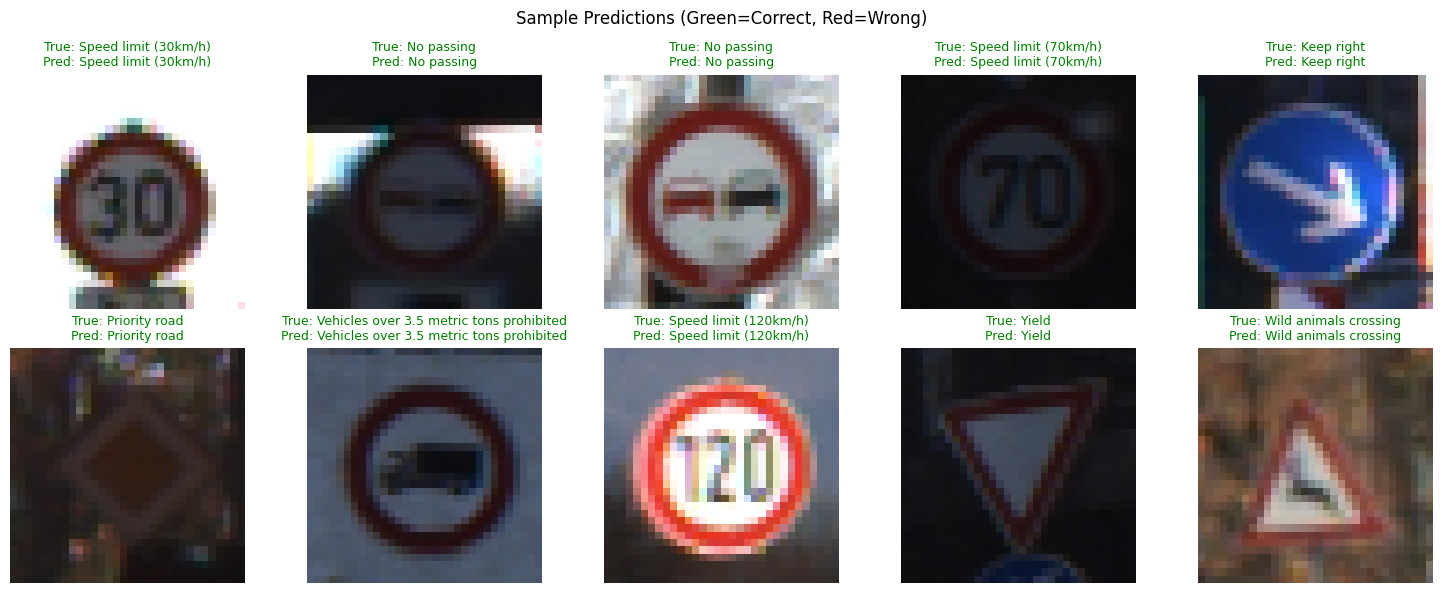

In [38]:
# Section 15: Visualize Sample Predictions (robust)
if 'model' not in globals() or model is None:
    model = load_model(MODEL_FILE_KERAS)
if 'X_test' not in globals() or 'y_test' not in globals() or 'y_pred' not in globals():
    # Recompute predictions if needed
    class_dirs = sorted([d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))])
    images, labels = [], []
    for cls in class_dirs:
        folder = os.path.join(DATA_DIR, cls)
        for img_name in os.listdir(folder):
            img_path = os.path.join(folder, img_name)
            img = cv2.imread(img_path)
            if img is None:
                continue
            img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
            images.append(img)
            labels.append(int(cls))
    X = np.array(images, dtype=np.float32) / 255.0
    y_numeric = np.array(labels, dtype=np.int32)
    from tensorflow.keras.utils import to_categorical
    y_onehot = to_categorical(y_numeric, NUM_CLASSES)
    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_onehot, test_size=0.2, random_state=42, stratify=y_onehot.argmax(axis=1)
    )
    probs = model.predict(X_test, verbose=0)
    y_pred = probs.argmax(axis=1)
    y_true = y_test.argmax(axis=1)

indices = np.random.choice(len(X_test), size=10, replace=False)
plt.figure(figsize=(15, 6))
for i, idx in enumerate(indices):
    img = (X_test[idx] * 255).astype(np.uint8)
    true_idx = y_true[idx]
    pred_idx = y_pred[idx]
    true_name = class_labels.get(int(true_idx), str(true_idx))
    pred_name = class_labels.get(int(pred_idx), str(pred_idx))
    color = 'green' if true_idx == pred_idx else 'red'
    plt.subplot(2, 5, i+1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f"True: {true_name}\nPred: {pred_name}", color=color, fontsize=9)
    plt.axis('off')
plt.suptitle("Sample Predictions (Green=Correct, Red=Wrong)")
plt.tight_layout()
plt.show()

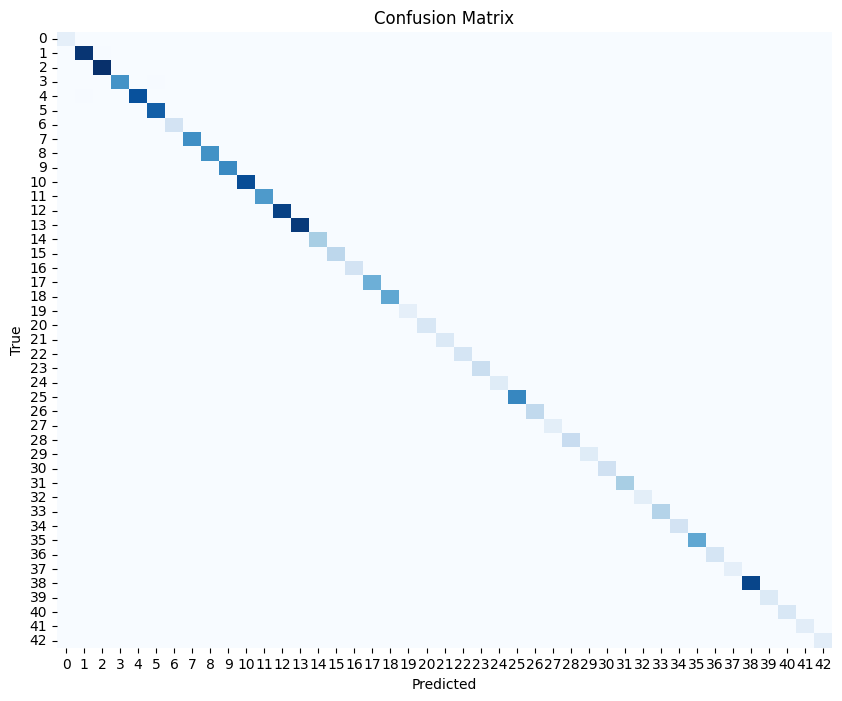

              precision    recall  f1-score   support

           0      1.000     1.000     1.000        42
           1      0.995     0.993     0.994       444
           2      0.991     1.000     0.996       450
           3      0.996     0.989     0.993       282
           4      0.997     0.992     0.995       396
           5      0.984     0.992     0.988       372
           6      1.000     1.000     1.000        84
           7      1.000     0.990     0.995       288
           8      0.993     0.996     0.995       282
           9      1.000     1.000     1.000       294
          10      1.000     0.995     0.998       402
          11      0.992     1.000     0.996       264
          12      1.000     1.000     1.000       420
          13      1.000     1.000     1.000       432
          14      1.000     1.000     1.000       156
          15      1.000     1.000     1.000       126
          16      0.988     1.000     0.994        84
          17      1.000    

In [39]:
# Section 16: Confusion Matrix and Classification Report (robust)
if 'model' not in globals() or model is None:
    model = load_model(MODEL_FILE_KERAS)
if 'X_test' not in globals() or 'y_test' not in globals() or 'y_pred' not in globals() or 'y_true' not in globals():
    class_dirs = sorted([d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))])
    images, labels = [], []
    for cls in class_dirs:
        folder = os.path.join(DATA_DIR, cls)
        for img_name in os.listdir(folder):
            img_path = os.path.join(folder, img_name)
            img = cv2.imread(img_path)
            if img is None:
                continue
            img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
            images.append(img)
            labels.append(int(cls))
    X = np.array(images, dtype=np.float32) / 255.0
    y_numeric = np.array(labels, dtype=np.int32)
    from tensorflow.keras.utils import to_categorical
    y_onehot = to_categorical(y_numeric, NUM_CLASSES)
    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_onehot, test_size=0.2, random_state=42, stratify=y_onehot.argmax(axis=1)
    )
    probs = model.predict(X_test, verbose=0)
    y_pred = probs.argmax(axis=1)
    y_true = y_test.argmax(axis=1)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()
print(classification_report(y_true, y_pred, digits=3))

In [40]:
# Section 17: Single Image Prediction Helper Function
def predict_image(img_path, model_ref=None, top_k=3, return_names=True):
    if model_ref is None:
        model_ref = model
    img = cv2.imread(img_path)
    if img is None:
        raise ValueError("Image not found:", img_path)
    img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
    arr = img.astype(np.float32) / 255.0
    arr = np.expand_dims(arr, axis=0)
    probs = model_ref.predict(arr, verbose=0)[0]
    top_indices = probs.argsort()[-top_k:][::-1]
    if return_names:
        return [
            (class_labels.get(int(i), str(int(i))), float(probs[i]))
            for i in top_indices
        ]
    else:
        return [(int(i), float(probs[i])) for i in top_indices]
sample_img = os.path.join(TEST_DIR, random.choice(os.listdir(TEST_DIR)))
print("Top-3 prediction for sample image:")
for name, p in predict_image(sample_img):
    print(f" - {name}: {p:.3f}")

Top-3 prediction for sample image:
 - Speed limit (80km/h): 1.000
 - Speed limit (60km/h): 0.000
 - Speed limit (50km/h): 0.000


In [41]:
# Section 18: Automated Startup Inference (Run after restart without retraining)
if os.path.exists(MODEL_FILE_KERAS):
    auto_model = load_model(MODEL_FILE_KERAS)
    print("Auto-loaded model ✅")
    test_img_path = os.path.join(TEST_DIR, random.choice(os.listdir(TEST_DIR)))
    print("Quick check:", test_img_path)
    print("Top-3:", predict_image(test_img_path, model_ref=auto_model))
else:
    print("Saved model not found yet. Run training once to create it.")

Auto-loaded model ✅
Quick check: /Users/komalsaivulchi/Downloads/traffic-sign-detection-main/archive/Test/03317.png
Top-3: [('No entry', 1.0), ('Stop', 3.8067765824267205e-18), ('No passing for vehicles over 3.5 metric tons', 5.355038041458603e-26)]
Top-3: [('No entry', 1.0), ('Stop', 3.8067765824267205e-18), ('No passing for vehicles over 3.5 metric tons', 5.355038041458603e-26)]


/Users/komalsaivulchi/Downloads/traffic-sign-detection-main/.venv/lib/python3.9/site-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 14 variables whereas the saved optimizer has 26 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
